In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
import xgboost as xgb
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
import optuna
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/march-machine-learning-mania-2026/Conferences.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/WNCAATourneyDetailedResults.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/WRegularSeasonCompactResults.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/MNCAATourneySeedRoundSlots.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/MGameCities.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/WSecondaryTourneyCompactResults.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/WGameCities.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/MSeasons.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/WNCAATourneySlots.csv
/kaggle/input/competitions/march-machine-learning

In [2]:
COMP = Path("/kaggle/input/competitions/march-machine-learning-mania-2026/")

M_tourney = pd.read_csv(COMP / "MNCAATourneyCompactResults.csv")
W_tourney = pd.read_csv(COMP / "WNCAATourneyCompactResults.csv")

M_rs_cmp    = pd.read_csv(COMP / "MRegularSeasonCompactResults.csv")
W_rs_cmp    = pd.read_csv(COMP / "WRegularSeasonCompactResults.csv")
M_rs_det    = pd.read_csv(COMP / "MRegularSeasonDetailedResults.csv")
W_rs_det    = pd.read_csv(COMP / "WRegularSeasonDetailedResults.csv")

M_seeds_df  = pd.read_csv(COMP / "MNCAATourneySeeds.csv")
W_seeds_df  = pd.read_csv(COMP / "WNCAATourneySeeds.csv")


M_massey_df = pd.read_csv(COMP/ "MMasseyOrdinals.csv")


In [3]:
def elorating(df, k=20, initial=1500):
    elo = {}

    for _, row in df.sort_values(["Season", "DayNum"]).iterrows():
        w = row["WTeamID"]
        l = row["LTeamID"]

        r_w = elo.get(w, initial)
        r_l = elo.get(l, initial)

        exp_w = 1 / (1 + 10 ** ((r_l - r_w) / 400))

        elo[w] = r_w + k * (1 - exp_w)
        elo[l] = r_l + k * (0 - (1 - exp_w))

    return elo

def parse_seed(seeds_df):
    seeds_df = seeds_df.copy()

    seeds_df["Seed"] = (
        seeds_df["Seed"]
        .astype(str)
        .str.extract(r'(\d+)')   
        .astype(float)           
    )

    return seeds_df
    


def massey_features(massey, season):
    df = massey[massey["Season"] == season].copy()

    # sort so latest ranking comes last
    df = df.sort_values("RankingDayNum")

    # take last available ranking per team
    df = df.groupby("TeamID").tail(1)

    result = df.groupby("TeamID")["OrdinalRank"].agg(["median", "min"]).reset_index()

    return result
    
def box_stats(detailed, season):
    df = detailed[detailed["Season"]==season]
    g = df.groupby("WTeamID")
    stats = pd.DataFrame({
        "FGPct": g["WFGM"].sum() / g["WFGA"].sum(),
        "Reb": g["WOR"].mean() + g["WDR"].mean(),
        "Ast": g["WAst"].mean(),
        "TO": g["WTO"].mean()
    }).reset_index()
    return stats
    





  

In [4]:
def compute_stats_for_season(compact, season):

    seasons = [season-1, season-2, season-3]
    df = compact[compact["Season"].isin(seasons)].copy()

    if df.empty:
        return pd.DataFrame()  # no data available

    df["PtDiff"] = df["WScore"] - df["LScore"]

    # winners
    w = df[["Season", "WTeamID", "PtDiff"]].copy()
    w.columns = ["Season", "TeamID", "PtDiff"]
    w["Win"] = 1

    # losers
    l = df[["Season", "LTeamID", "PtDiff"]].copy()
    l.columns = ["Season", "TeamID", "PtDiff"]
    l["Win"] = 0

    all_games = pd.concat([w, l])

    stats = all_games.groupby(["Season", "TeamID"]).agg({
        "Win": "mean",
        "PtDiff": "mean"
    }).reset_index()

    stats.rename(columns={"Win": "WinPct", "PtDiff": "AvgPtDiff"}, inplace=True)

    weights = {season-1: 3, season-2: 2, season-3: 1}
    stats["w"] = stats["Season"].map(weights)

    final = stats.groupby("TeamID").apply(
        lambda g: pd.Series({
            "WinPct": np.average(g["WinPct"], weights=g["w"]),
            "AvgPtDiff": np.average(g["AvgPtDiff"], weights=g["w"])
        })
    ).reset_index()

    final["Season"] = season

    return final

In [5]:
def build_matches(df):
    rows = []

    for _, r in df.iterrows():
        w = r["WTeamID"]
        l = r["LTeamID"]
        s = r["Season"]

        # original (winner as TeamA)
        rows.append([s, w, l, 1])

        # flipped (loser as TeamA)
        rows.append([s, l, w, 0])

    return pd.DataFrame(rows, columns=["Season", "TeamA", "TeamB", "Result"])

In [6]:
train_m = build_matches(M_tourney)
train_w = build_matches(W_tourney)

In [7]:
def elo_feature(rs_cmp,train):
    elo_dict = elorating(rs_cmp)
    elo_df = pd.DataFrame(list(elo_dict.items()), columns=["TeamID", "Elo"])
# TeamA Elo
    train = train.merge(elo_df, left_on="TeamA", right_on="TeamID", how="left")
    train = train.rename(columns={"Elo": "EloA"}).drop(columns=["TeamID"])

# TeamB Elo
    train = train.merge(elo_df, left_on="TeamB", right_on="TeamID", how="left")
    train = train.rename(columns={"Elo": "EloB"}).drop(columns=["TeamID"])

    return train

def seed_feature(seeds_df,train):
    seedschange = parse_seed(seeds_df)
    train = train.merge(
    seedschange,
    left_on=["Season", "TeamA"],
    right_on=["Season", "TeamID"],
    how="left"
    )

    train = train.rename(columns={"Seed": "SeedA"})
    train = train.drop(columns=["TeamID"])

    train = train.merge(seedschange,
                   left_on = ["Season","TeamB"],
                   right_on = ["Season","TeamID"],
                   how = "left")
    train = train.rename(columns={"Seed": "SeedB"})
    train = train.drop(columns=["TeamID"])
    return train
    
def massey_feature(massey, train):
    massey_all = []

    
    for s in train["Season"].unique():
        m = massey_features(massey, s)
        m["Season"] = s
        massey_all.append(m)

    massey_df = pd.concat(massey_all)

    
    massey_A = massey_df.rename(columns={
        "TeamID": "TeamA",
        "median": "MasseyMedianA",
        "min": "MasseyMinA"
    })

    massey_B = massey_df.rename(columns={
        "TeamID": "TeamB",
        "median": "MasseyMedianB",
        "min": "MasseyMinB"
    })

    
    train = train.merge(massey_A, on=["Season", "TeamA"], how="left")
    train = train.merge(massey_B, on=["Season", "TeamB"], how="left")

   
    for col in ["MasseyMedianA", "MasseyMedianB", "MasseyMinA", "MasseyMinB"]:
        train[col] = train[col].fillna(200)

    return train
    
def box_feature(rs_det,train):
    all_stats = []

    for season in train["Season"].unique():
        s = box_stats(rs_det, season)
        s["Season"] = season
        all_stats.append(s)

    stats = pd.concat(all_stats, ignore_index=True)

    stats_A = stats.rename(columns={
        "WTeamID": "TeamA",
        "FGPct": "FGPct_A",
        "Reb": "Reb_A",
        "Ast": "Ast_A",
        "TO": "TO_A"
        })

    stats_B = stats.rename(columns={
        "WTeamID": "TeamB",
        "FGPct": "FGPct_B",
        "Reb": "Reb_B",
        "Ast": "Ast_B",
        "TO": "TO_B"
        })

    train = train.merge(stats_A, on=["Season", "TeamA"], how="left")
    train = train.merge(stats_B, on=["Season", "TeamB"], how="left")
    train = train.dropna()

    return train

def compact_feature(rs_cmp,train):
    all_statsc = []

    for season in train["Season"].unique():
        s = compute_stats_for_season(rs_cmp, season)
        all_statsc.append(s)

    statsc = pd.concat(all_statsc, ignore_index=True)
    stats_A = statsc.rename(columns={
        "TeamID": "TeamA",
        "WinPct": "WinPct_A",
        "AvgPtDiff": "PtDiff_A"
        })

    stats_B = statsc.rename(columns={
        "TeamID": "TeamB",
        "WinPct": "WinPct_B",
        "AvgPtDiff": "PtDiff_B"
        })

    train = train.merge(stats_A, on=["Season", "TeamA"], how="left")
    train = train.merge(stats_B, on=["Season", "TeamB"], how="left")

    return train

In [8]:
train_m = elo_feature(M_rs_cmp,train_m)
train_m = seed_feature(M_seeds_df,train_m)
train_m = box_feature(M_rs_det,train_m)
train_m = compact_feature(M_rs_cmp,train_m)
#

/tmp/ipykernel_17/17226860.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final = stats.groupby("TeamID").apply(
/tmp/ipykernel_17/17226860.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final = stats.groupby("TeamID").apply(
/tmp/ipykernel_17/17226860.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping 

In [9]:
train_m = massey_feature(M_massey_df,train_m)

In [10]:
train_m

,Season,TeamA,TeamB,Result,EloA,EloB,SeedA,SeedB,FGPct_A,Reb_A,...,Ast_B,TO_B,WinPct_A,PtDiff_A,WinPct_B,PtDiff_B,MasseyMedianA,MasseyMinA,MasseyMedianB,MasseyMinB
0,2003,1421,1411,1,1388.757897,1201.870229,16.0,16.0,0.470745,38.692308,...,15.166667,16.333333,0.454907,13.786472,0.356888,13.946264,289.0,289,275.0,275
1,2003,1411,1421,0,1201.870229,1388.757897,16.0,16.0,0.475258,39.555556,...,16.307692,14.923077,0.356888,13.946264,0.454907,13.786472,275.0,275,289.0,289
2,2003,1112,1436,1,2115.381834,1526.555594,1.0,16.0,0.472548,43.000000,...,15.684211,13.473684,0.743129,13.364943,0.595238,12.099959,1.0,1,177.0,177
3,2003,1436,1112,0,1526.555594,2115.381834,16.0,1.0,0.473785,40.210526,...,18.200000,14.800000,0.595238,12.099959,0.743129,13.364943,177.0,177,1.0,1
4,2003,1113,1272,1,1765.894021,1725.558162,10.0,7.0,0.519364,39.222222,...,17.608696,14.086957,0.497126,13.975369,0.605556,14.500000,52.0,52,31.0,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2893,2025,1120,1196,0,1923.228892,2045.897309,1.0,1.0,0.487493,34.821429,...,16.566667,10.200000,0.746017,15.450368,0.608482,12.603274,2.0,2,1.0,1
2894,2025,1222,1181,1,2129.238159,2150.632860,1.0,1.0,0.466286,33.000000,...,17.161290,9.064516,0.887255,19.000000,0.767157,14.822610,6.0,6,3.0,3
2895,2025,1181,1222,0,2150.632860,2129.238159,1.0,1.0,0.492919,36.580645,...,12.266667,8.366667,0.767157,14.822610,0.887255,19.000000,3.0,3,6.0,6
2896,2025,1196,1222,1,2045.897309,2129.238159,1.0,1.0,0.478395,39.966667,...,12.266667,8.366667,0.608482,12.603274,0.887255,19.000000,1.0,1,6.0,6


In [11]:
# Target
y = train_m["Result"]

# Drop non-feature columns
X = train_m.drop(columns=["Result", "Season", "TeamA", "TeamB"])


In [12]:
# Core strength
X["EloDiff"] = X["EloA"] - X["EloB"]

# Seed (lower is better → reverse)
X["SeedDiff"] = X["SeedB"] - X["SeedA"]

# Shooting
X["FGPctDiff"] = X["FGPct_A"] - X["FGPct_B"]

# Rebounding
X["RebDiff"] = X["Reb_A"] - X["Reb_B"]

# Playmaking
X["AstDiff"] = X["Ast_A"] - X["Ast_B"]

# Turnovers (lower is better → reverse)
X["TODiff"] = X["TO_B"] - X["TO_A"]

# Performance
X["WinPctDiff"] = X["WinPct_A"] - X["WinPct_B"]
X["PtDiffDiff"] = X["PtDiff_A"] - X["PtDiff_B"]

#Massey (lower rank = better → reverse)
X["MasseyMedianDiff"] = X["MasseyMedianB"] - X["MasseyMedianA"]
X["MasseyMinDiff"] = X["MasseyMinB"] - X["MasseyMinA"]

In [13]:
cols_to_drop = [col for col in X.columns if col.endswith("_A") or col.endswith("_B")] + [
    "EloA","EloB","SeedA","SeedB",
   "MasseyMedianA","MasseyMedianB",
    "MasseyMinA","MasseyMinB"
]

X = X.drop(columns=cols_to_drop)

In [14]:
X

,EloDiff,SeedDiff,FGPctDiff,RebDiff,AstDiff,TODiff,WinPctDiff,PtDiffDiff,MasseyMedianDiff,MasseyMinDiff
0,186.887667,0.0,-0.004513,-0.863248,1.141026,1.410256,0.098019,-0.159792,-14.0,-14
1,-186.887667,0.0,0.004513,0.863248,-1.141026,-1.410256,-0.098019,0.159792,14.0,14
2,588.826240,15.0,-0.001237,2.789474,2.515789,-1.326316,0.147891,1.264984,176.0,176
3,-588.826240,-15.0,0.001237,-2.789474,-2.515789,1.326316,-0.147891,-1.264984,-176.0,-176
4,40.335859,-3.0,0.070937,-1.212560,-0.664251,0.198068,-0.108429,-0.524631,-21.0,-21
...,...,...,...,...,...,...,...,...,...,...
2893,-122.668418,0.0,0.009098,-5.145238,-0.209524,1.200000,0.137535,2.847094,-1.0,-1
2894,-21.394701,0.0,-0.026634,-3.580645,-4.894624,0.697849,0.120098,4.177390,-3.0,-3
2895,21.394701,0.0,0.026634,3.580645,4.894624,-0.697849,-0.120098,-4.177390,3.0,3
2896,-83.340849,0.0,0.012109,6.966667,4.300000,-1.833333,-0.278773,-6.396726,5.0,5


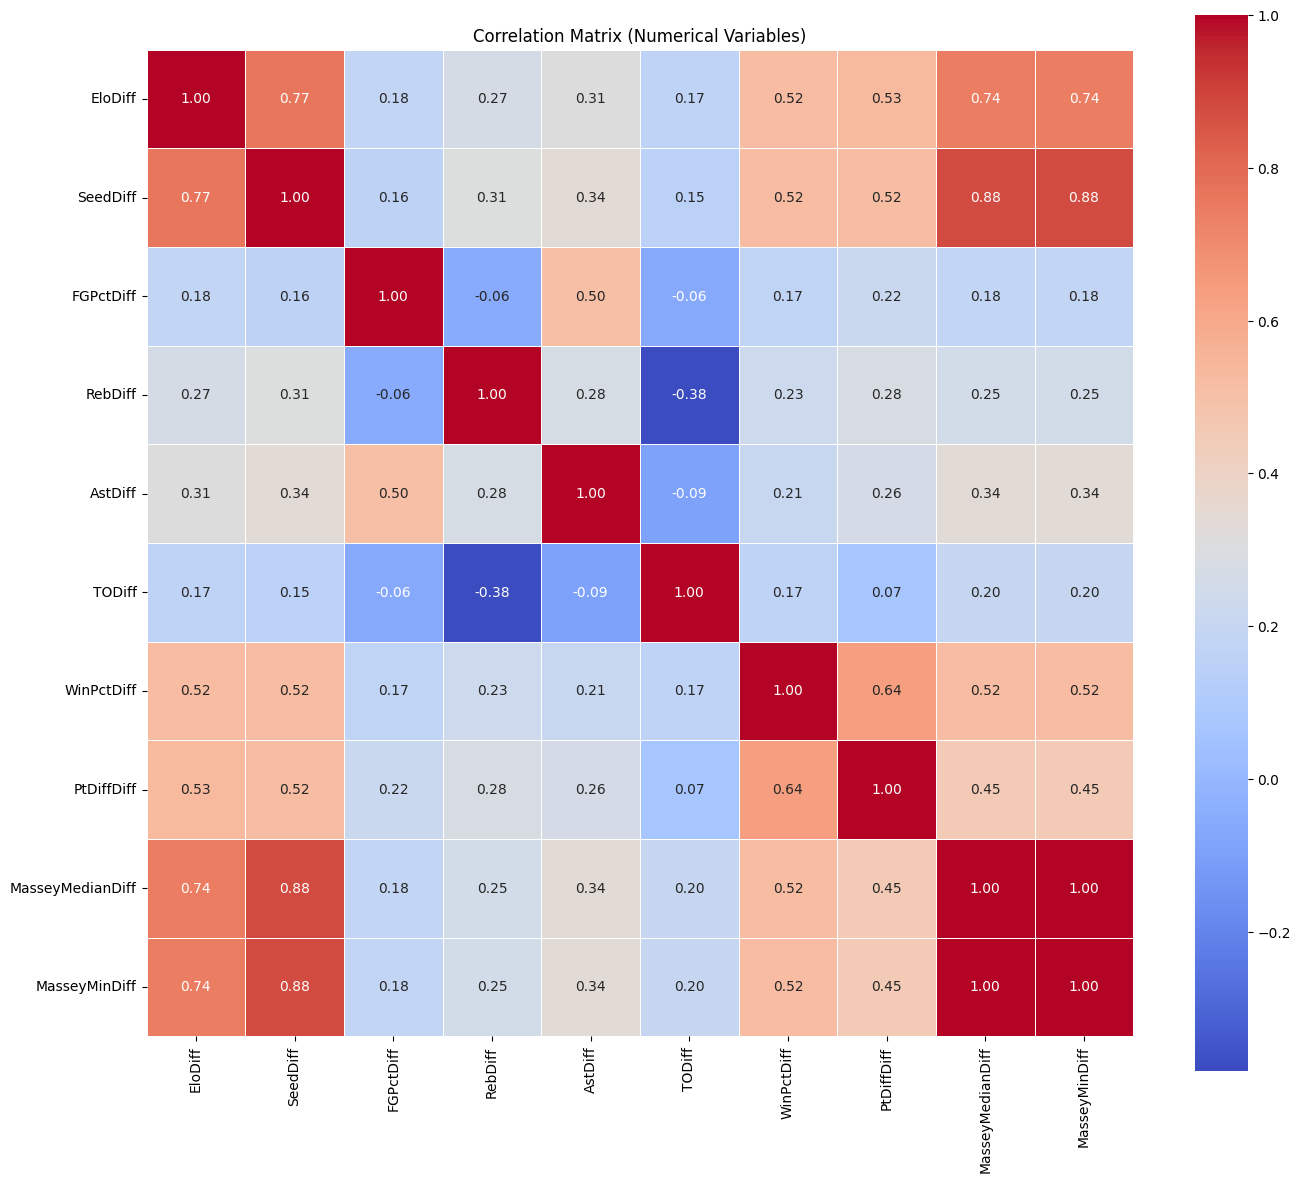

In [15]:
cor = X.corr()
plt.figure(figsize=(14,12))
sns.heatmap(
    cor,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix (Numerical Variables)")
plt.tight_layout()

In [16]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
numeric_transformer = RobustScaler()
X_train = numeric_transformer.fit_transform(X_train)
X_val = numeric_transformer.fit_transform(X_val)

In [18]:
y.value_counts()

Result
1    1449
0    1449
Name: count, dtype: int64

In [19]:
for n in [50, 100, 200, 300, 500]:
    for p in [0.01,0.03,0.05, 0.1]:
        
        model1 = XGBClassifier(
            n_estimators=n,
            max_depth=3,
            learning_rate=p,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )
        
        model1.fit(X_train, y_train)
        
        probs = model1.predict_proba(X_val)[:, 1]
        
        score = brier_score_loss(y_val, probs)
        
        print(f"n_estimators={n}, learning_rate={p}, Brier={score:.4f}")

n_estimators=50, learning_rate=0.01, Brier=0.2168
n_estimators=50, learning_rate=0.03, Brier=0.1985
n_estimators=50, learning_rate=0.05, Brier=0.1956
n_estimators=50, learning_rate=0.1, Brier=0.1964
n_estimators=100, learning_rate=0.01, Brier=0.2037
n_estimators=100, learning_rate=0.03, Brier=0.1953
n_estimators=100, learning_rate=0.05, Brier=0.1947
n_estimators=100, learning_rate=0.1, Brier=0.1965
n_estimators=200, learning_rate=0.01, Brier=0.1963
n_estimators=200, learning_rate=0.03, Brier=0.1961
n_estimators=200, learning_rate=0.05, Brier=0.1967
n_estimators=200, learning_rate=0.1, Brier=0.2001
n_estimators=300, learning_rate=0.01, Brier=0.1954
n_estimators=300, learning_rate=0.03, Brier=0.1965
n_estimators=300, learning_rate=0.05, Brier=0.1984
n_estimators=300, learning_rate=0.1, Brier=0.2035
n_estimators=500, learning_rate=0.01, Brier=0.1959
n_estimators=500, learning_rate=0.03, Brier=0.1982
n_estimators=500, learning_rate=0.05, Brier=0.2012
n_estimators=500, learning_rate=0.1, Br

In [20]:
model_m = XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )

model_m.fit(X_train, y_train)
        
probs = model_m.predict_proba(X_val)[:, 1]
        
score = brier_score_loss(y_val, probs)
        
print(f"n_estimators={n}, learning_rate={p}, Brier={score:.4f}")

n_estimators=500, learning_rate=0.1, Brier=0.1947


In [21]:
train_w = elo_feature(W_rs_cmp,train_w)
train_w = seed_feature(W_seeds_df,train_w)
train_w = box_feature(W_rs_det,train_w)
train_w = compact_feature(W_rs_cmp,train_w)


/tmp/ipykernel_17/17226860.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final = stats.groupby("TeamID").apply(
/tmp/ipykernel_17/17226860.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final = stats.groupby("TeamID").apply(
/tmp/ipykernel_17/17226860.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping 

In [22]:
# Target
y = train_w["Result"]

# Drop non-feature columns
X = train_w.drop(columns=["Result", "Season", "TeamA", "TeamB"])


In [23]:
X

,EloA,EloB,SeedA,SeedB,FGPct_A,Reb_A,Ast_A,TO_A,FGPct_B,Reb_B,Ast_B,TO_B,WinPct_A,PtDiff_A,WinPct_B,PtDiff_B
0,2042.670789,1445.467532,4.0,13.0,0.506605,44.521739,16.260870,17.086957,0.438522,39.185185,15.629630,16.296296,0.818750,18.035764,0.700941,15.110719
1,1445.467532,2042.670789,13.0,4.0,0.438522,39.185185,15.629630,16.296296,0.506605,44.521739,16.260870,17.086957,0.700941,15.110719,0.818750,18.035764
2,1559.995126,2026.683408,8.0,9.0,0.431327,44.047619,15.714286,16.857143,0.439885,40.545455,16.772727,15.181818,0.620072,12.154936,0.664987,15.078495
3,2026.683408,1559.995126,9.0,8.0,0.439885,40.545455,16.772727,15.181818,0.431327,44.047619,15.714286,16.857143,0.664987,15.078495,0.620072,12.154936
4,2125.545817,1209.324928,2.0,15.0,0.441901,43.814815,15.148148,17.666667,0.389816,37.789474,13.315789,13.368421,0.817204,19.301075,0.532834,13.112567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1917,2267.406504,2354.931601,1.0,2.0,0.488865,39.100000,20.966667,14.733333,0.515576,33.580645,21.387097,10.290323,0.738067,16.475843,0.847445,23.905110
1918,2383.757612,2268.818270,1.0,1.0,0.474211,39.233333,17.333333,11.800000,0.476142,36.161290,16.870968,12.419355,0.989247,28.290659,0.821691,21.555453
1919,2268.818270,2383.757612,1.0,1.0,0.476142,36.161290,16.870968,12.419355,0.474211,39.233333,17.333333,11.800000,0.821691,21.555453,0.989247,28.290659
1920,2354.931601,2383.757612,2.0,1.0,0.515576,33.580645,21.387097,10.290323,0.474211,39.233333,17.333333,11.800000,0.847445,23.905110,0.989247,28.290659


In [24]:
# Core strength
X["EloDiff"] = X["EloA"] - X["EloB"]

# Seed (lower is better → reverse)
X["SeedDiff"] = X["SeedB"] - X["SeedA"]

# Shooting
X["FGPctDiff"] = X["FGPct_A"] - X["FGPct_B"]

# Rebounding
X["RebDiff"] = X["Reb_A"] - X["Reb_B"]

# Playmaking
X["AstDiff"] = X["Ast_A"] - X["Ast_B"]

# Turnovers (lower is better → reverse)
X["TODiff"] = X["TO_B"] - X["TO_A"]

# Performance
X["WinPctDiff"] = X["WinPct_A"] - X["WinPct_B"]
X["PtDiffDiff"] = X["PtDiff_A"] - X["PtDiff_B"]

cols_to_drop = [col for col in X.columns if col.endswith("_A") or col.endswith("_B")] + [
    "EloA","EloB","SeedA","SeedB",
    
]

X = X.drop(columns=cols_to_drop)

In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
numeric_transformer = RobustScaler()
X_train = numeric_transformer.fit_transform(X_train)
X_val = numeric_transformer.fit_transform(X_val)

In [26]:
for n in [50, 100, 200, 300, 500]:
    for p in [0.01,0.03,0.05, 0.1]:
        
        model2 = XGBClassifier(
            n_estimators=n,
            max_depth=3,
            learning_rate=p,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )
        
        model2.fit(X_train, y_train)
        
        probs = model2.predict_proba(X_val)[:, 1]
        
        score = brier_score_loss(y_val, probs)
        
        print(f"n_estimators={n}, learning_rate={p}, Brier={score:.4f}")

n_estimators=50, learning_rate=0.01, Brier=0.1952
n_estimators=50, learning_rate=0.03, Brier=0.1642
n_estimators=50, learning_rate=0.05, Brier=0.1597
n_estimators=50, learning_rate=0.1, Brier=0.1607
n_estimators=100, learning_rate=0.01, Brier=0.1720
n_estimators=100, learning_rate=0.03, Brier=0.1594
n_estimators=100, learning_rate=0.05, Brier=0.1595
n_estimators=100, learning_rate=0.1, Brier=0.1605
n_estimators=200, learning_rate=0.01, Brier=0.1593
n_estimators=200, learning_rate=0.03, Brier=0.1595
n_estimators=200, learning_rate=0.05, Brier=0.1607
n_estimators=200, learning_rate=0.1, Brier=0.1660
n_estimators=300, learning_rate=0.01, Brier=0.1580
n_estimators=300, learning_rate=0.03, Brier=0.1595
n_estimators=300, learning_rate=0.05, Brier=0.1622
n_estimators=300, learning_rate=0.1, Brier=0.1741
n_estimators=500, learning_rate=0.01, Brier=0.1580
n_estimators=500, learning_rate=0.03, Brier=0.1634
n_estimators=500, learning_rate=0.05, Brier=0.1705
n_estimators=500, learning_rate=0.1, Br

In [27]:
model_w = XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.01,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )

model_w.fit(X_train, y_train)
        
probs = model_w.predict_proba(X_val)[:, 1]
        
score = brier_score_loss(y_val, probs)
        
print(f"Brier={score:.4f}")

Brier=0.1580


In [28]:
from itertools import combinations

teams = M_seeds_df[M_seeds_df["Season"] == 2026]["TeamID"].unique()

matchups = list(combinations(teams, 2))

test = pd.DataFrame(matchups, columns=["TeamA", "TeamB"])  # IMPORTANT

test["Season"] = 2026
test["ID"] = "2026_" + test["TeamA"].astype(str) + "_" + test["TeamB"].astype(str)

In [29]:
test = elo_feature(M_rs_cmp, test)
test = seed_feature(M_seeds_df, test)
test = massey_feature(M_massey_df, test)
test = box_feature(M_rs_det, test)
test = compact_feature(M_rs_cmp, test)

/tmp/ipykernel_17/17226860.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final = stats.groupby("TeamID").apply(


In [30]:
test

,TeamA,TeamB,Season,ID,EloA,EloB,SeedA,SeedB,MasseyMedianA,MasseyMinA,...,Ast_A,TO_A,FGPct_B,Reb_B,Ast_B,TO_B,WinPct_A,PtDiff_A,WinPct_B,PtDiff_B
0,1181,1163,2026,2026_1181_1163,2150.632860,2064.156381,1.0,2.0,2.0,2,...,17.093750,10.250000,0.492643,33.758621,18.896552,10.241379,0.833333,18.200368,0.778669,15.714201
1,1181,1277,2026,2026_1181_1277,2150.632860,2015.382970,1.0,3.0,2.0,2,...,17.093750,10.250000,0.494126,37.440000,18.880000,10.960000,0.833333,18.200368,0.703161,12.362985
2,1181,1242,2026,2026_1181_1242,2150.632860,1992.979797,1.0,4.0,2.0,2,...,17.093750,10.250000,0.486706,38.000000,15.826087,10.347826,0.833333,18.200368,0.676341,14.188460
3,1181,1385,2026,2026_1181_1385,2150.632860,2060.297087,1.0,5.0,2.0,2,...,17.093750,10.250000,0.474596,35.321429,17.000000,9.892857,0.833333,18.200368,0.734106,12.945930
4,1181,1257,2026,2026_1181_1257,2150.632860,1874.574312,1.0,6.0,2.0,2,...,17.093750,10.250000,0.499640,37.913043,19.130435,11.217391,0.833333,18.200368,0.501225,13.860600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2273,1218,1474,2026,2026_1218_1474,1546.710495,1465.795266,13.0,15.0,103.0,103,...,14.318182,12.954545,0.506568,33.150000,17.200000,9.150000,0.521013,10.961746,0.486559,11.651434
2274,1218,1254,2026,2026_1218_1254,1546.710495,1398.494301,13.0,16.0,103.0,103,...,14.318182,12.954545,0.498501,32.791667,14.166667,12.250000,0.521013,10.961746,0.328568,13.228065
2275,1244,1474,2026,2026_1244_1474,1521.313157,1465.795266,14.0,15.0,139.0,139,...,14.277778,12.222222,0.506568,33.150000,17.200000,9.150000,0.533180,8.397158,0.486559,11.651434
2276,1244,1254,2026,2026_1244_1254,1521.313157,1398.494301,14.0,16.0,139.0,139,...,14.277778,12.222222,0.498501,32.791667,14.166667,12.250000,0.533180,8.397158,0.328568,13.228065


In [31]:
test["EloDiff"] = test["EloA"] - test["EloB"]
test["SeedDiff"] = test["SeedA"] - test["SeedB"]

test["FGPctDiff"] = test["FGPct_A"] - test["FGPct_B"]
test["RebDiff"]   = test["Reb_A"] - test["Reb_B"]
test["AstDiff"]   = test["Ast_A"] - test["Ast_B"]
test["TODiff"]    = test["TO_A"] - test["TO_B"]

test["WinPctDiff"] = test["WinPct_A"] - test["WinPct_B"]
test["PtDiffDiff"] = test["PtDiff_A"] - test["PtDiff_B"]

test["MasseyMedianDiff"] = test["MasseyMedianB"] - test["MasseyMedianA"]
test["MasseyMinDiff"] = test["MasseyMinB"] - test["MasseyMinA"]

In [32]:
features = ['EloDiff', 'SeedDiff', 'FGPctDiff', 'RebDiff',
            'AstDiff', 'TODiff', 'WinPctDiff', 'PtDiffDiff', 'MasseyMedianDiff', 'MasseyMinDiff']

X_test = test[features]

In [33]:
X_test= numeric_transformer.fit_transform(X_test)
test["Pred"] = model_m.predict_proba(X_test)[:, 1]

In [34]:
submission = test[["ID", "Pred"]]
submission.to_csv("submission1.csv", index=False)

In [35]:
df_man_predict = pd.read_csv("submission1.csv")

In [36]:
df_man_predict

,ID,Pred
0,2026_1181_1163,0.498629
1,2026_1181_1277,0.508434
2,2026_1181_1242,0.526062
3,2026_1181_1385,0.437911
4,2026_1181_1257,0.454227
...,...,...
2273,2026_1218_1474,0.698006
2274,2026_1218_1254,0.587336
2275,2026_1244_1474,0.713833
2276,2026_1244_1254,0.641110


In [37]:
from itertools import combinations

teams = W_seeds_df[W_seeds_df["Season"] == 2026]["TeamID"].unique()

matchups = list(combinations(teams, 2))

test1 = pd.DataFrame(matchups, columns=["TeamA", "TeamB"])  # IMPORTANT

test1["Season"] = 2026
test1["ID"] = "2026_" + test1["TeamA"].astype(str) + "_" + test1["TeamB"].astype(str)

In [38]:
test1 = elo_feature(W_rs_cmp, test1)
test1 = seed_feature(W_seeds_df, test1)

test1 = box_feature(W_rs_det, test1)
test1 = compact_feature(W_rs_cmp, test1)

/tmp/ipykernel_17/17226860.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final = stats.groupby("TeamID").apply(


In [39]:
test1

,TeamA,TeamB,Season,ID,EloA,EloB,SeedA,SeedB,FGPct_A,Reb_A,Ast_A,TO_A,FGPct_B,Reb_B,Ast_B,TO_B,WinPct_A,PtDiff_A,WinPct_B,PtDiff_B
0,3163,3435,2026,2026_3163_3435,2354.931601,1999.082704,1.0,2.0,0.525288,33.470588,23.705882,12.352941,0.476620,33.074074,19.703704,12.296296,0.880867,27.190879,0.644825,20.033434
1,3163,3326,2026,2026_3163_3326,2354.931601,2120.689701,1.0,3.0,0.525288,33.470588,23.705882,12.352941,0.468412,34.576923,19.000000,12.653846,0.880867,27.190879,0.806070,20.050503
2,3163,3314,2026,2026_3163_3314,2354.931601,2074.889299,1.0,4.0,0.525288,33.470588,23.705882,12.352941,0.470446,36.769231,17.153846,13.076923,0.880867,27.190879,0.714263,14.781784
3,3163,3268,2026,2026_3163_3268,2354.931601,2043.591415,1.0,5.0,0.525288,33.470588,23.705882,12.352941,0.477682,39.217391,17.913043,14.956522,0.880867,27.190879,0.715659,17.712769
4,3163,3323,2026,2026_3163_3323,2354.931601,2111.375217,1.0,6.0,0.525288,33.470588,23.705882,12.352941,0.491632,32.818182,15.500000,11.727273,0.880867,27.190879,0.829077,23.402935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2273,3453,3239,2026,2026_3453_3239,1766.783170,1482.983259,13.0,15.0,0.450796,32.250000,17.791667,11.708333,0.422337,35.454545,12.590909,14.636364,0.833333,17.838542,0.377807,13.671132
2274,3453,3465,2026,2026_3453_3465,1766.783170,1559.621734,13.0,16.0,0.450796,32.250000,17.791667,11.708333,0.425950,38.260870,16.956522,13.869565,0.833333,17.838542,0.593582,12.924059
2275,3158,3239,2026,2026_3158_3239,1624.374179,1482.983259,14.0,15.0,0.411550,36.080000,13.920000,11.680000,0.422337,35.454545,12.590909,14.636364,0.665079,17.156085,0.377807,13.671132
2276,3158,3465,2026,2026_3158_3465,1624.374179,1559.621734,14.0,16.0,0.411550,36.080000,13.920000,11.680000,0.425950,38.260870,16.956522,13.869565,0.665079,17.156085,0.593582,12.924059


In [40]:
test1["EloDiff"] = test1["EloA"] - test1["EloB"]
test1["SeedDiff"] = test1["SeedA"] - test1["SeedB"]

test1["FGPctDiff"] = test1["FGPct_A"] - test1["FGPct_B"]
test1["RebDiff"]   = test1["Reb_A"] - test1["Reb_B"]
test1["AstDiff"]   = test1["Ast_A"] - test1["Ast_B"]
test1["TODiff"]    = test1["TO_A"] - test1["TO_B"]

test1["WinPctDiff"] = test1["WinPct_A"] - test1["WinPct_B"]
test1["PtDiffDiff"] = test1["PtDiff_A"] - test1["PtDiff_B"]



In [41]:
features = ['EloDiff', 'SeedDiff', 'FGPctDiff', 'RebDiff',
            'AstDiff', 'TODiff', 'WinPctDiff', 'PtDiffDiff']

X_test = test1[features]

In [42]:
X_test= numeric_transformer.fit_transform(X_test)
test1["Pred"] = model_w.predict_proba(X_test)[:, 1]

In [43]:
submission = test1[["ID", "Pred"]]
submission.to_csv("submission2.csv", index=False)

In [44]:
df_woman_predict = pd.read_csv("submission2.csv")

In [45]:
df_woman_predict

,ID,Pred
0,2026_3163_3435,0.807144
1,2026_3163_3326,0.649114
2,2026_3163_3314,0.625160
3,2026_3163_3268,0.663514
4,2026_3163_3323,0.457717
...,...,...
2273,2026_3453_3239,0.643951
2274,2026_3453_3465,0.529431
2275,2026_3158_3239,0.682106
2276,2026_3158_3465,0.476160


In [46]:
df1 = pd.read_csv("submission1.csv")
df2 = pd.read_csv("submission2.csv")

df = pd.concat([df1, df2], ignore_index=True)

df.to_csv("submission.csv", index=False)